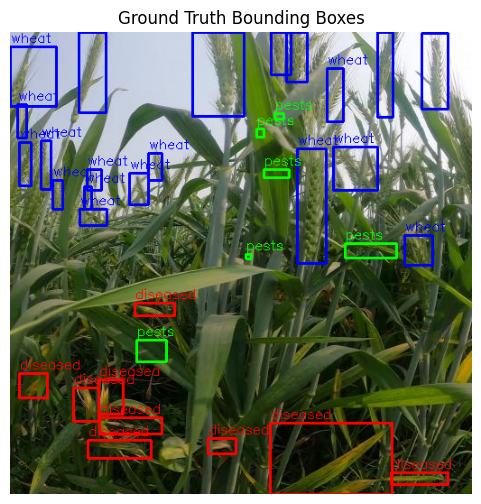

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

base="/Users/ahmadgill/Documents/GitHub/LUMS-Academics/Second Semester/RoboTics641/Lab5/Robotics_AssignmentLab5Final/train"

image_folder=os.path.join(base,"images")
label_folder=os.path.join(base,"labels")

colors={
2:(255,0,0),
1:(0,255,0),
0:(0,0,255)
}

names={
0:"diseased",
1:"pests",
2:"wheat"
}

for f in os.listdir(image_folder):

    if not f.endswith(".jpg"):
        continue

    img_path=os.path.join(image_folder,f)
    txt_path=os.path.join(label_folder,f.replace(".jpg",".txt"))

    if not os.path.exists(txt_path):
        continue

    img=cv2.imread(img_path)
    h,w,_=img.shape

    with open(txt_path) as file:
        lines=file.readlines()

    for line in lines:

        c,xc,yc,bw,bh=map(float,line.split())
        c=int(c)

        xmin=int((xc-bw/2)*w)
        ymin=int((yc-bh/2)*h)
        xmax=int((xc+bw/2)*w)
        ymax=int((yc+bh/2)*h)

        cv2.rectangle(img,(xmin,ymin),(xmax,ymax),colors[c],2)
        cv2.putText(img,names[c],(xmin,ymin-5),cv2.FONT_HERSHEY_SIMPLEX,0.5,colors[c],1)

    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Ground Truth Bounding Boxes")
    plt.show()

    break